In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("C:/Users/Dell Laptop/Downloads/student_placement_synthetic.csv")


### **Dimensions & Basic Info**

In [7]:
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(df.info())

--- Dataset Shape ---
Rows: 100000, Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-n

### **Missing Value Analysis**

In [14]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
branch                           0
college_tier                     0
cgpa                             0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
dtype: int64


### **Duplicate Check**

In [18]:
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

Total Duplicate Rows: 0


### **Summary statistics**

In [21]:
print(df.describe().T)

                              count       mean        std    min    25%  \
cgpa                       100000.0   7.206381   0.925235   4.00   6.58   
backlogs                   100000.0   0.547010   0.862727   0.00   0.00   
coding_skills              100000.0   5.995147   1.496302   1.00   5.00   
dsa_score                  100000.0   5.500711   1.781961   1.00   4.30   
aptitude_score             100000.0  64.990511  11.990892  20.00  56.80   
communication_skills       100000.0   5.990614   1.496552   1.00   5.00   
ml_knowledge               100000.0   4.508752   1.968278   0.00   3.20   
system_design              100000.0   4.008210   1.778405   0.00   2.80   
internships                100000.0   1.095040   0.940264   0.00   0.00   
projects_count             100000.0   2.397280   1.242829   0.00   1.00   
certifications             100000.0   1.499850   1.114070   0.00   1.00   
hackathons                 100000.0   0.745840   0.884189   0.00   0.00   
open_source_contributions

### **Categorical Unique Value Counts**

In [22]:
print(df.select_dtypes('object').nunique())

branch          7
college_tier    3
dtype: int64


### **Categorical Unique Value Counts**

In [23]:
df.sample(5)

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
71379,ECE,Tier-2,5.93,1,8.8,7.9,46.2,5.4,3.4,7.0,0,3,1,2,0,0,1,18.12
44914,IT,Tier-2,8.97,2,5.2,5.0,68.3,6.7,5.0,2.5,2,1,3,0,1,3,1,19.24
32490,IT,Tier-3,7.68,0,5.3,5.6,100.0,6.9,4.3,6.4,1,3,0,0,0,2,0,NaN
59638,IT,Tier-2,7.20,0,4.8,6.0,54.8,6.9,4.1,2.3,0,5,3,0,0,0,1,13.78
75779,ME,Tier-2,7.90,0,5.0,5.9,48.7,8.1,5.3,3.3,2,3,0,0,0,1,0,NaN


In [51]:
# ─── 1. THEME & COLORS ────────────────────────────────────────
BG, CARD, BORDER = '#0A0E1A', '#111827', '#1F2937'
T1, T2, T3, T4, T5 = '#10B981', '#F59E0B', '#3B82F6', '#EF4444', '#A78BFA'
WHITE, GREY, LGREY = '#F9FAFB', '#6B7280', '#9CA3AF'

plt.rcParams.update({
    'font.family': 'sans-serif', 'figure.facecolor': BG, 'axes.facecolor': CARD,
    'axes.edgecolor': BORDER, 'axes.labelcolor': LGREY, 'xtick.color': LGREY,
    'ytick.color': LGREY, 'text.color': WHITE, 'grid.color': BORDER,
    'grid.linestyle': '--', 'grid.alpha': 0.6, 'axes.spines.top': False, 
    'axes.spines.right': False
})

# ─── 2. HELPER FUNCTIONS ───────────────────────────────────────
def card(ax, title='', xlabel='', ylabel='', grid=True):
    ax.set_facecolor(CARD)
    for sp in ax.spines.values(): sp.set_color(BORDER); sp.set_linewidth(0.8)
    ax.tick_params(colors=LGREY, labelsize=9)
    if grid: ax.grid(axis='y', alpha=0.4)
    if title: ax.set_title(title, color=WHITE, fontsize=11, fontweight='bold', pad=12)
    if xlabel: ax.set_xlabel(xlabel, color=LGREY, fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, color=LGREY, fontsize=9)

def stat_box(ax, text, color=T3):
    ax.text(0.97, 0.97, text, transform=ax.transAxes, ha='right', va='top', 
            fontsize=9, color=WHITE, bbox=dict(facecolor=BG, edgecolor=color, boxstyle='round,pad=0.5'))

# ─── 3. PREP DATA ──────────────────────────────────────────────
# Make sure df is already loaded: df = pd.read_csv("...")
placed = df[df['placement_status'] == 1]
unplaced = df[df['placement_status'] == 0]

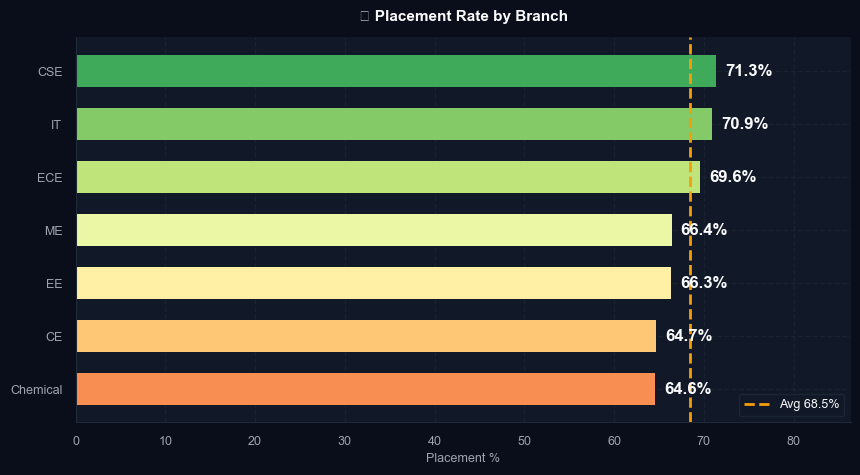

In [52]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
card(ax, '① Placement Rate by Branch', xlabel='Placement %', grid=False)

branch_rate = df.groupby('branch')['placement_status'].mean().sort_values() * 100
overall_avg = df['placement_status'].mean() * 100
cmap1 = plt.cm.RdYlGn(np.linspace(0.25, 0.85, len(branch_rate)))

bars1 = ax.barh(branch_rate.index, branch_rate.values, color=cmap1, edgecolor='none', height=0.6)
ax.axvline(overall_avg, color=T2, lw=2, linestyle='--', label=f'Avg {overall_avg:.1f}%')

for bar, val in zip(bars1, branch_rate.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', color=WHITE, fontweight='bold')

ax.set_xlim(0, max(branch_rate.values) + 15)
ax.legend(fontsize=9, loc='lower right')
plt.show() 

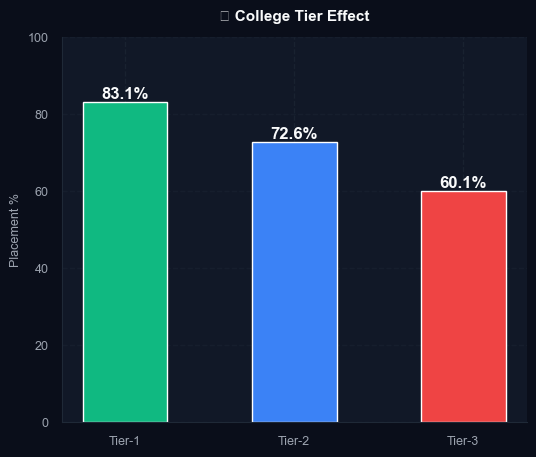

In [55]:
fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
card(ax, '② College Tier Effect', ylabel='Placement %')

tiers = ['Tier-1', 'Tier-2', 'Tier-3']
tier_rates = [df[df['college_tier']==t]['placement_status'].mean()*100 for t in tiers]
bars2 = ax.bar(tiers, tier_rates, color=[T1, T3, T4], width=0.5)

for bar, val in zip(bars2, tier_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', color=WHITE, fontweight='bold')

ax.set_ylim(0, 100)
plt.show() 

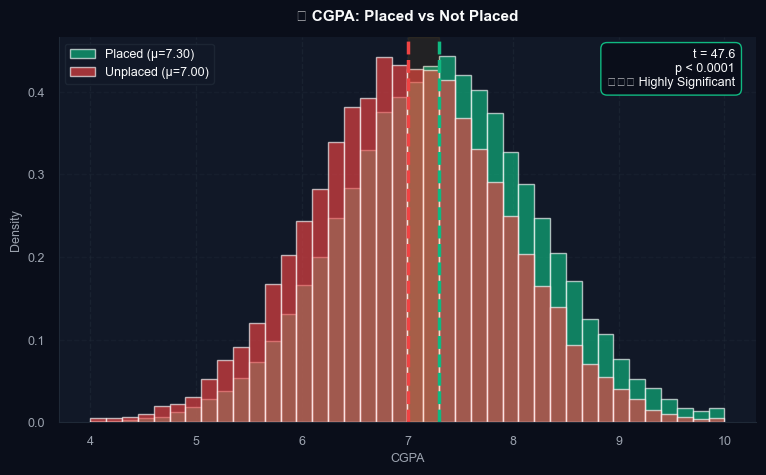

In [56]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
card(ax, '③ CGPA: Placed vs Not Placed', 'CGPA', 'Density')

ax.hist(placed['cgpa'], bins=40, density=True, alpha=0.65, color=T1, label=f'Placed (μ={placed["cgpa"].mean():.2f})')
ax.hist(unplaced['cgpa'], bins=40, density=True, alpha=0.65, color=T4, label=f'Unplaced (μ={unplaced["cgpa"].mean():.2f})')

ax.axvline(placed['cgpa'].mean(), color=T1, lw=2.5, linestyle='--')
ax.axvline(unplaced['cgpa'].mean(), color=T4, lw=2.5, linestyle='--')
ax.axvspan(unplaced['cgpa'].mean(), placed['cgpa'].mean(), alpha=0.08, color=T2)

t_stat, t_p = stats.ttest_ind(placed['cgpa'], unplaced['cgpa'])
stat_box(ax, f't = {t_stat:.1f}\np < 0.0001\n★★★ Highly Significant', T1)

ax.legend(fontsize=9)
plt.show() 

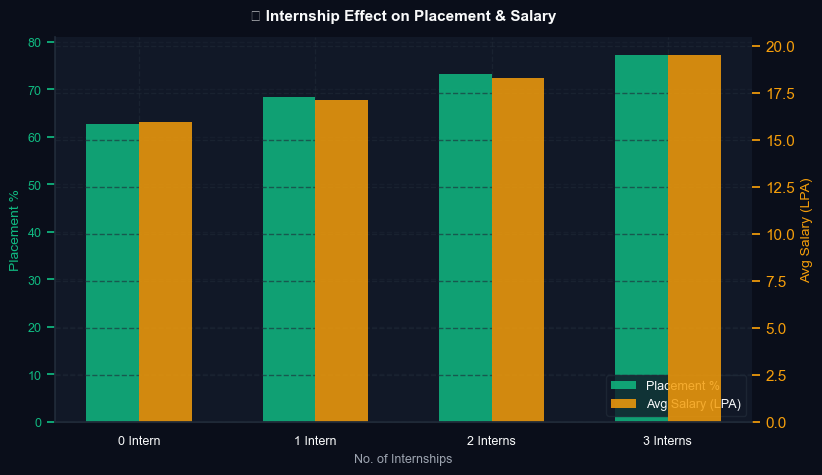

In [60]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
card(ax, '④ Internship Effect on Placement & Salary', 'No. of Internships')

x_in = [0, 1, 2, 3]
place_rates = [df[df['internships']==i]['placement_status'].mean()*100 for i in x_in]
sal_avgs    = [placed[placed['internships']==i]['salary_package_lpa'].mean() for i in x_in]

# Dual axis setup
ax_r = ax.twinx()
bars_p = ax.bar([x-0.15 for x in x_in], place_rates, width=0.3, color=T1, alpha=0.85, label='Placement %', edgecolor='none')
bars_s = ax_r.bar([x+0.15 for x in x_in], sal_avgs, width=0.3, color=T2, alpha=0.85, label='Avg Salary (LPA)', edgecolor='none')

ax.set_ylabel('Placement %', color=T1, fontsize=10)
ax_r.set_ylabel('Avg Salary (LPA)', color=T2, fontsize=10)
ax.tick_params(axis='y', colors=T1)
ax_r.tick_params(axis='y', colors=T2)
ax_r.set_facecolor(CARD)

ax.set_xticks(x_in)
ax.set_xticklabels(['0 Intern','1 Intern','2 Interns','3 Interns'], color=WHITE, fontsize=9)

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_r.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='lower right')

plt.title("", color=WHITE, pad=15, fontweight='bold')
plt.show()

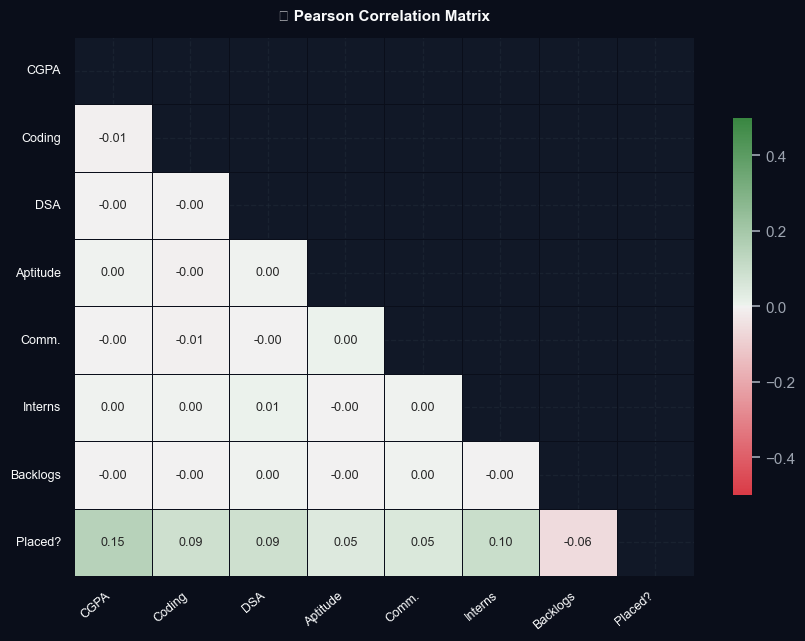

In [61]:
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
card(ax, '⑤ Pearson Correlation Matrix', grid=False)

corr_cols = ['cgpa','coding_skills','dsa_score','aptitude_score',
             'communication_skills','internships','backlogs','placement_status']
corr_labels = ['CGPA','Coding','DSA','Aptitude','Comm.','Interns','Backlogs','Placed?']

corr_mat = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
cmap_corr = sns.diverging_palette(10, 130, as_cmap=True)

sns.heatmap(corr_mat, mask=mask, cmap=cmap_corr, vmax=0.5, vmin=-0.5, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            ax=ax, linewidths=0.5, linecolor=BG, cbar_kws={'shrink': 0.7})

ax.set_xticklabels(corr_labels, rotation=40, ha='right', fontsize=9, color=WHITE)
ax.set_yticklabels(corr_labels, fontsize=9, color=WHITE)

plt.show()

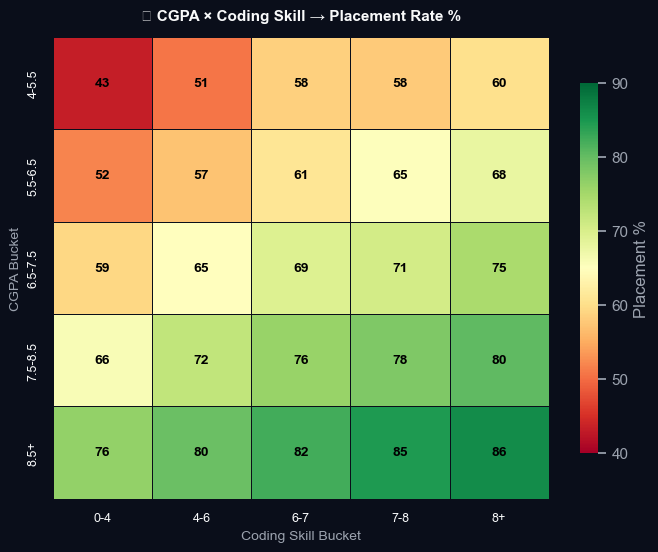

In [62]:
# Create temporary bins for analysis
df_temp = df.copy()
df_temp['cgpa_bin']   = pd.cut(df_temp['cgpa'], bins=[4, 5.5, 6.5, 7.5, 8.5, 10], labels=['4-5.5','5.5-6.5','6.5-7.5','7.5-8.5','8.5+'])
df_temp['coding_bin'] = pd.cut(df_temp['coding_skills'], bins=[0, 4, 6, 7, 8, 10], labels=['0-4','4-6','6-7','7-8','8+'])

pivot_bkt = df_temp.groupby(['cgpa_bin','coding_bin'], observed=True)['placement_status'].mean() * 100
pivot_bkt = pivot_bkt.unstack()

fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
card(ax, '⑥ CGPA × Coding Skill → Placement Rate %', grid=False)

sns.heatmap(pivot_bkt, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax,
            vmin=40, vmax=90, linewidths=0.5, linecolor=BG,
            annot_kws={'size': 10, 'color': 'black', 'fontweight': 'bold'},
            cbar_kws={'shrink': 0.8, 'label': 'Placement %'})

ax.set_xlabel('Coding Skill Bucket', color=LGREY, fontsize=10)
ax.set_ylabel('CGPA Bucket', color=LGREY, fontsize=10)
for lbl in ax.get_xticklabels() + ax.get_yticklabels(): 
    lbl.set_color(WHITE)

plt.show()

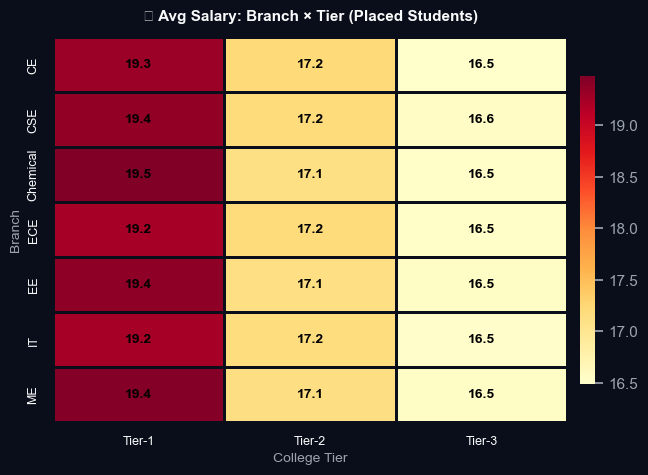

In [64]:
pivot_sal = placed.pivot_table('salary_package_lpa', index='branch', columns='college_tier', aggfunc='mean')
pivot_sal = pivot_sal[['Tier-1','Tier-2','Tier-3']] # Sort columns

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
card(ax, '⑦ Avg Salary: Branch × Tier (Placed Students)', grid=False)

sns.heatmap(pivot_sal, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.8, linecolor=BG, annot_kws={'size': 10, 'color': 'black', 'fontweight':'bold'},
            cbar_kws={'shrink': 0.8, 'pad': 0.02})

ax.tick_params(colors=WHITE, labelsize=9)
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_color(WHITE)
ax.set_xlabel('College Tier', color=LGREY, fontsize=10)
ax.set_ylabel('Branch', color=LGREY, fontsize=10)

plt.show()

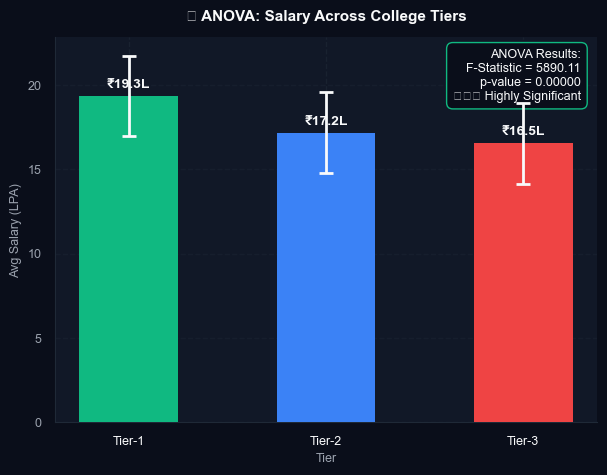

In [65]:
# Helper function for significance label
def sig_label(p):
    if p < 0.001: return '★★★ Highly Significant'
    if p < 0.01:  return '★★  Significant'
    if p < 0.05:  return '★   Marginally Sig.'
    return '✗   Not Significant'

fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
card(ax, '① ANOVA: Salary Across College Tiers', 'Tier', 'Avg Salary (LPA)')

tiers = ['Tier-1', 'Tier-2', 'Tier-3']
tier_sal_groups = [placed[placed['college_tier']==t]['salary_package_lpa'].values for t in tiers]

# Run ANOVA Test
f_stat, p_val = stats.f_oneway(*tier_sal_groups)

means = [np.mean(g) for g in tier_sal_groups]
stds  = [np.std(g)  for g in tier_sal_groups]

bars = ax.bar(tiers, means, yerr=stds, color=[T1, T3, T4],
              edgecolor='none', width=0.5, capsize=5,
              error_kw=dict(ecolor=WHITE, lw=2, capthick=2), zorder=3)

for t, m in zip(tiers, means):
    ax.text(t, m+0.5, f'₹{m:.1f}L', ha='center', color=WHITE, fontsize=10, fontweight='bold')

# Show Test Results on Graph
stat_box(ax, f'ANOVA Results:\nF-Statistic = {f_stat:.2f}\np-value = {p_val:.5f}\n{sig_label(p_val)}', 
         T1 if p_val < 0.05 else T4)

ax.tick_params(axis='x', colors=WHITE)
plt.show()

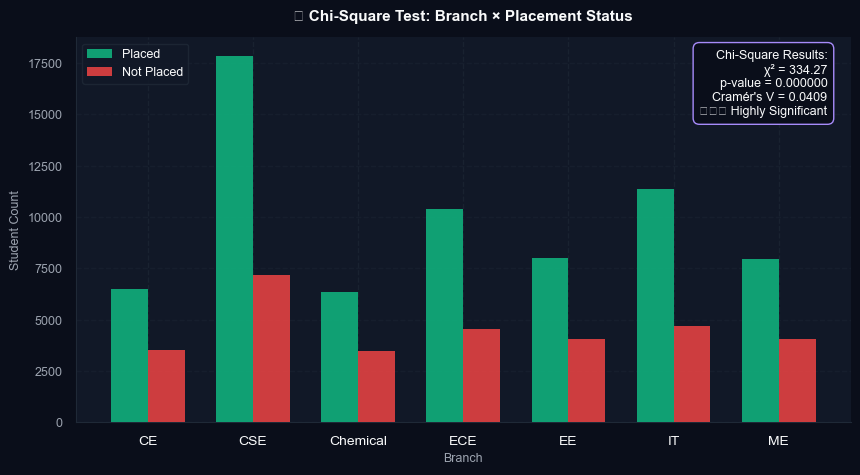

In [66]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
card(ax, '② Chi-Square Test: Branch × Placement Status', 'Branch', 'Student Count')

# Create Contingency Table
ct = pd.crosstab(df['branch'], df['placement_status'])

# Run Chi-Square Test
chi2_stat, chi_p, dof, expected = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2_stat / (len(df) * min(ct.shape)-1))

x_chi = np.arange(len(ct))
w_chi = 0.35

ax.bar(x_chi - w_chi/2, ct[1], w_chi, color=T1, label='Placed', edgecolor='none', alpha=0.85, zorder=3)
ax.bar(x_chi + w_chi/2, ct[0], w_chi, color=T4, label='Not Placed', edgecolor='none', alpha=0.85, zorder=3)

ax.set_xticks(x_chi)
ax.set_xticklabels(ct.index, color=WHITE, fontsize=10)
ax.legend(fontsize=9)

# Show Test Results on Graph
stat_box(ax, f'Chi-Square Results:\nχ² = {chi2_stat:.2f}\np-value = {chi_p:.6f}\nCramér\'s V = {cramers_v:.4f}\n{sig_label(chi_p)}', T5)

plt.show()

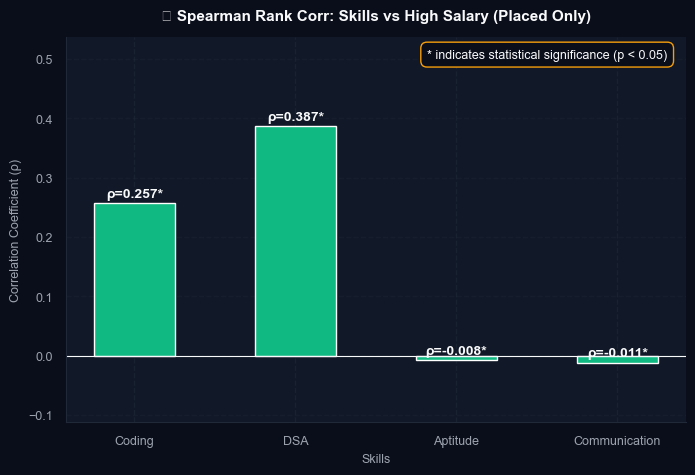

In [67]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
card(ax, '③ Spearman Rank Corr: Skills vs High Salary (Placed Only)', 'Skills', 'Correlation Coefficient (ρ)')

# Calculating Spearman correlation for specific skills against Salary
skills_to_test = ['coding_skills', 'dsa_score', 'aptitude_score', 'communication_skills']
labels = ['Coding', 'DSA', 'Aptitude', 'Communication']
rho_values = []
p_values = []

for skill in skills_to_test:
    rho, p = stats.spearmanr(placed[skill], placed['salary_package_lpa'])
    rho_values.append(rho)
    p_values.append(p)

colors = [T1 if p < 0.05 else GREY for p in p_values]
bars = ax.bar(labels, rho_values, color=colors, width=0.5)

for bar, r, p in zip(bars, rho_values, p_values):
    sig = '*' if p < 0.05 else ''
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'ρ={r:.3f}{sig}', ha='center', color=WHITE, fontweight='bold', fontsize=10)

ax.axhline(0, color=WHITE, linewidth=0.8)
ax.set_ylim(min(rho_values)-0.1, max(rho_values)+0.15)

stat_box(ax, "* indicates statistical significance (p < 0.05)", T2)

plt.show()

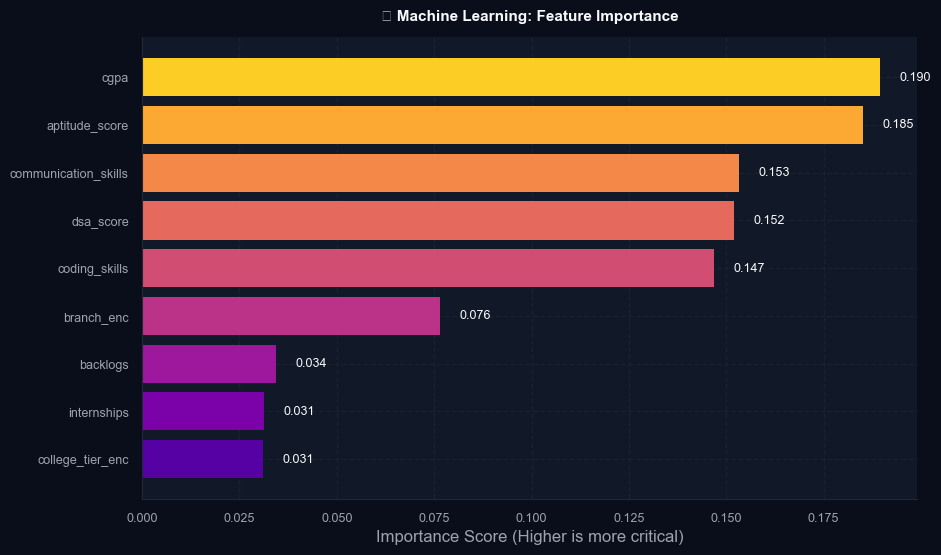

In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Prep data for ML
df_ml = df.copy()
le = LabelEncoder()
df_ml['branch_enc'] = le.fit_transform(df_ml['branch'])
df_ml['college_tier_enc'] = le.fit_transform(df_ml['college_tier'])

# Select features
features = ['cgpa','backlogs','coding_skills','dsa_score','aptitude_score',
            'communication_skills','internships','branch_enc','college_tier_enc']
X = df_ml[features]
y = df_ml['placement_status']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Model
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Plot Feature Importance
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
card(ax, '① Machine Learning: Feature Importance', grid=False)

importances = pd.Series(rf.feature_importances_, index=features).sort_values()
cmap_fi = plt.cm.plasma(np.linspace(0.15, 0.9, len(importances)))

bars = ax.barh(importances.index, importances.values, color=cmap_fi, edgecolor='none')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', color=WHITE, fontsize=9)

ax.set_xlabel('Importance Score (Higher is more critical)', color=LGREY)
plt.show()

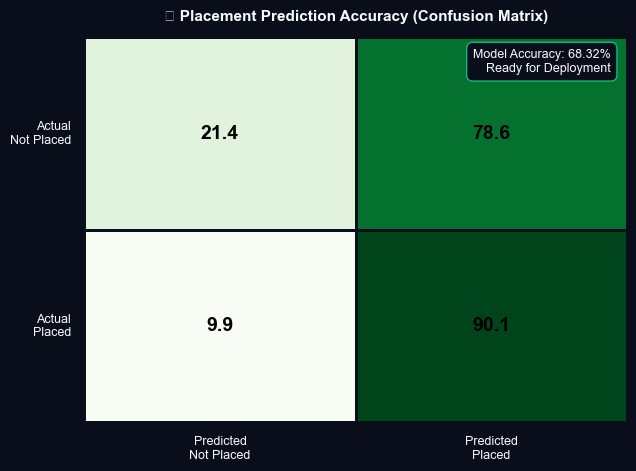

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
card(ax, '② Placement Prediction Accuracy (Confusion Matrix)', grid=False)

y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens', ax=ax,
            linewidths=1, linecolor=BG, cbar=False,
            annot_kws={'size': 14, 'fontweight': 'bold', 'color': 'black'})

ax.set_xticklabels(['Predicted\nNot Placed','Predicted\nPlaced'], color=WHITE)
ax.set_yticklabels(['Actual\nNot Placed','Actual\nPlaced'], color=WHITE, rotation=0)

accuracy = rf.score(X_test, y_test)
stat_box(ax, f'Model Accuracy: {accuracy*100:.2f}%\nReady for Deployment', T1)

plt.show()

# ─── LOGIC TO TEST A CUSTOM PROFILE ───
def test_student_chances(cgpa, backlogs, coding, dsa, aptitude, comm, intern, branch, tier):
    # Encoding: Make sure branch and tier match the LabelEncoder's mapping
    b_enc = le.transform([branch])[0] if branch in le.classes_ else 0
    t_enc = 0 # Adjust based on your tier encoding (e.g., Tier-1 = 0, Tier-2 = 1)
    
    profile = [[cgpa, backlogs, coding, dsa, aptitude, comm, intern, b_enc, t_enc]]
    prob = rf.predict_proba(profile)[0][1]
    
    print(f"\n🎯 Custom Profile Placement Probability: {prob*100:.1f}%")

# Example: A 6.5 CGPA student with killer coding skills and 2 internships
# Branch 'CSE' and Tier 'Tier-2'
# test_student_chances(6.5, 0, 9, 8, 7, 8, 2, 'CSE', 'Tier-2')

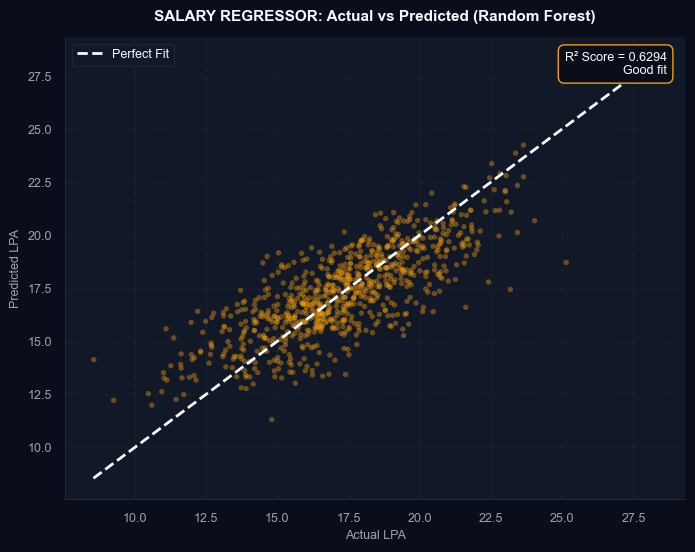

In [77]:
df_sal = df[df['placement_status'] == 1].copy()


le = LabelEncoder()
df_sal['branch_enc'] = le.fit_transform(df_sal['branch'])
df_sal['college_tier_enc'] = le.fit_transform(df_sal['college_tier'])


feat_cols = ['cgpa','backlogs','coding_skills','dsa_score','aptitude_score',
             'communication_skills','internships','branch_enc','college_tier_enc']

X_sal = df_sal[feat_cols]
y_sal = df_sal['salary_package_lpa']


Xtr, Xte, ytr, yte = train_test_split(X_sal, y_sal, test_size=0.2, random_state=42)


rfr = RandomForestRegressor(n_estimators=80, random_state=42, n_jobs=-1)
rfr.fit(Xtr, ytr)


ypred = rfr.predict(Xte)
r2_sal = rfr.score(Xte, yte) 


fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
card(ax, 'SALARY REGRESSOR: Actual vs Predicted (Random Forest)', 'Actual LPA', 'Predicted LPA')


ax.scatter(yte[:800], ypred[:800], s=15, alpha=0.4, color=T2, edgecolors='none')


mn, mx = yte.min(), yte.max()
ax.plot([mn, mx], [mn, mx], color=WHITE, lw=2, linestyle='--', label='Perfect Fit')

ax.legend(fontsize=9)
stat_box(ax, f'R² Score = {r2_sal:.4f}\n{"Good fit" if r2_sal>0.5 else "Moderate fit"}', T2)

plt.show()

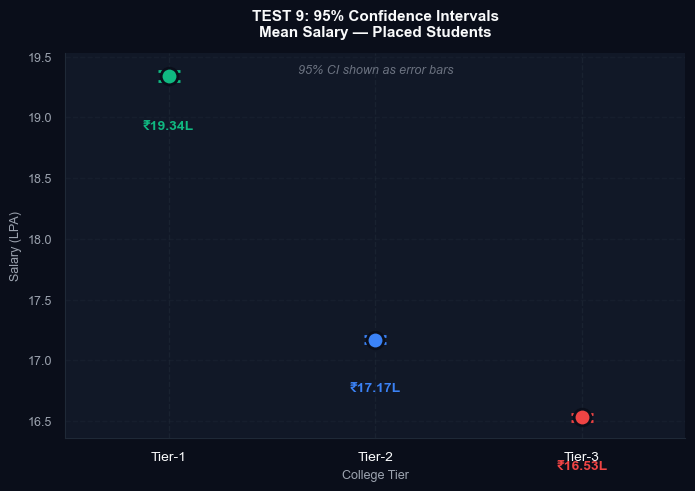

In [75]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
card(ax, 'TEST 9: 95% Confidence Intervals\nMean Salary — Placed Students', 'College Tier', 'Salary (LPA)')

ci_data = []
# Calculate Mean and 95% CI for each tier
for t in tiers:
    g = placed[placed['college_tier']==t]['salary_package_lpa'].dropna()
    m = g.mean()
    se = stats.sem(g)
    ci = stats.t.interval(0.95, df=len(g)-1, loc=m, scale=se)
    ci_data.append((t, m, ci[0], ci[1]))

colors = [T1, T3, T4]
for i, (t, m, lo, hi) in enumerate(ci_data):
    col = colors[i]
    # Plot Error Bars
    ax.errorbar(i, m, yerr=[[m-lo], [hi-m]], fmt='o',
                color=col, markersize=12, capsize=8, capthick=2.5,
                elinewidth=2.5, markeredgecolor=BG, markeredgewidth=2, zorder=4)
    # Add Text Label
    ax.text(i, lo - 0.4, f'₹{m:.2f}L', ha='center', color=col, fontsize=10, fontweight='bold')

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(tiers, color=WHITE, fontsize=10)

# Add informative text
ax.text(0.5, 0.97, '95% CI shown as error bars', transform=ax.transAxes, 
        ha='center', va='top', color=GREY, fontsize=9, style='italic')

ax.set_xlim(-0.5, 2.5)
plt.show()

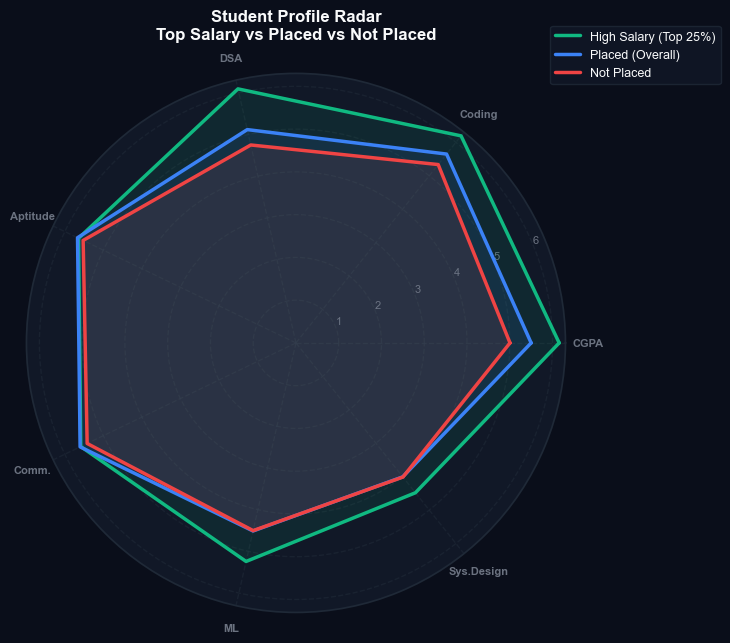

In [78]:
fig = plt.figure(figsize=(7, 7), facecolor=BG)
# Radar chart ke liye projection='polar' zaroori hai
ax_radar = fig.add_subplot(111, polar=True)
ax_radar.set_facecolor(CARD)

skill_cols = ['cgpa','coding_skills','dsa_score','aptitude_score','communication_skills','ml_knowledge','system_design']
radar_cats = ['CGPA', 'Coding', 'DSA', 'Aptitude', 'Comm.', 'ML', 'Sys.Design']
N_r = len(radar_cats)

# Radar Angles setup
angles_r = [n / float(N_r) * 2 * np.pi for n in range(N_r)]
angles_r += angles_r[:1] # Circle close karne ke liye

# Normalize Data (Sabhi skills ko 0-10 ke scale par laana)
def norm10(series): 
    return (series - df[series.name].min()) / (df[series.name].max() - df[series.name].min()) * 10

# Create 3 Profiles to compare
placed = df[df['placement_status'] == 1]
unplaced = df[df['placement_status'] == 0]

profiles = {
    'High Salary (Top 25%)': placed[placed['salary_package_lpa'] >= placed['salary_package_lpa'].quantile(0.75)],
    'Placed (Overall)': placed,
    'Not Placed': unplaced,
}
radar_colors = [T1, T3, T4] # Green, Blue, Red

# Plot Each Profile
for (pname, pdata), rcol in zip(profiles.items(), radar_colors):
    vals = [norm10(pdata[c]).mean() for c in skill_cols]
    vals += vals[:1] # Circle close
    
    ax_radar.plot(angles_r, vals, color=rcol, lw=2.5, label=pname)
    ax_radar.fill(angles_r, vals, color=rcol, alpha=0.1) # Halka fill color

# Styling Radar
ax_radar.set_xticks(angles_r[:-1])
ax_radar.set_xticklabels(radar_cats, color=WHITE, fontsize=10, fontweight='bold')
ax_radar.set_title('Student Profile Radar\nTop Salary vs Placed vs Not Placed', color=WHITE, fontsize=12, fontweight='bold', pad=25)

# Axis lines & legend
ax_radar.tick_params(colors=GREY, labelsize=8)
ax_radar.grid(color=BORDER, linestyle='--')
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9, facecolor=CARD, edgecolor=BORDER, labelcolor=WHITE)

plt.show()